In [29]:
import sys
import os
import math
import time
import pathlib
import pickle
import numpy as np
import pandas as pd
import seaborn as sns

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import MobileNetV2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, mean_absolute_error, mean_squared_error

# Dataset paths

In [30]:
# Dataset paths
train_dir = pathlib.Path('/kaggle/input/brain-tumor-mri-dataset/Training')
test_dir = pathlib.Path('/kaggle/input/brain-tumor-mri-dataset/Testing')

img_height = 224
img_width = 224
batch_size = 32
epochs = 50

# Data augmentation

In [31]:
# Dataset loading
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=batch_size,
    shuffle=True,
    interpolation="bilinear",
    label_mode="int",
)

# Get class names
class_names = train_ds.class_names
print("Classes in the dataset:", class_names)

# Normalize and apply data augmentation
normalization_layer = tf.keras.layers.Rescaling(1./255)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=batch_size,
)

val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=batch_size,
)

test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Classes in the dataset: ['glioma', 'meningioma', 'notumor', 'pituitary']
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
Found 1311 files belonging to 4 classes.


In [32]:
def get_class_weights(train_ds, class_names):
    print("Calculating class weights...")
    
    labels = []
    for image_batch, label_batch in train_ds:
        labels.append(label_batch.numpy())

    labels = np.concatenate(labels)
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

    class_weight_dict = {i: class_weights[i] for i in range(len(class_names))}
    print("Class weights calculated.")
    return class_weight_dict

class_weight_dict = get_class_weights(train_ds, class_names)

Calculating class weights...
Class weights calculated.


In [34]:
# General Imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.metrics import confusion_matrix

# Neural Network imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam

# Image augmentation importrs
from tensorflow.keras.utils import load_img
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomTranslation

# Training Model callbacks
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

# Check if GPU is available
print(f'Tensorflow Version: {tf.__version__}')
print("GPU Available:", tf.config.list_physical_devices('GPU')[0])

Tensorflow Version: 2.17.1
GPU Available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [44]:
for image, label in train_ds.take(1):
    print("Label shape:", label.shape)
    print("Label:", label)


Label shape: (32,)
Label: tf.Tensor([3 0 2 3 1 3 2 1 1 1 3 2 2 3 1 2 3 3 2 3 1 2 3 3 2 0 0 2 1 1 0 2], shape=(32,), dtype=int32)


In [45]:
# # Building model
image_size=(224, 224,3)
model = Sequential([
    # Input tensor shape
    Input(image_size),
    
    # Convolutional layer 1
    Conv2D(64, (5, 5), activation="relu"),
    MaxPooling2D(pool_size=(3, 3)),

    # Convolutional layer 2
    Conv2D(64, (5, 5), activation="relu"),
    MaxPooling2D(pool_size=(3, 3)),

    # Convolutional layer 3
    Conv2D(128, (4, 4), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolutional layer 4
    Conv2D(128, (4, 4), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),

    # Dense layers 
    Dense(512, activation="relu"),
    Dense(len(class_names), activation="softmax")

])

# Model summary
model.summary()

# COompilng model with Adam optimizer
optimizer = Adam(learning_rate=0.001, beta_1=0.85, beta_2=0.9925)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics= ['accuracy'])



import os
import json
import time
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

def train_custom_model(model, model_name, train_ds, val_ds, test_ds, 
                       learning_rate=0.001, epochs=50, class_weight=None, 
                       extra_callbacks=None):

    # Create save directory
    save_dir = '/kaggle/working/'
    os.makedirs(save_dir, exist_ok=True)

    # Compile model (if not compiled already)
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.85, beta_2=0.9925)
    # model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    print(f"\nSummary of {model_name}:")
    model.summary()

    # File paths
    model_path = os.path.join(save_dir, f'{model_name}.keras')
    best_model_path = os.path.join(save_dir, f'{model_name}_best.keras')
    history_path = os.path.join(save_dir, f'{model_name}_history.json')
    eval_path = os.path.join(save_dir, f'{model_name}_evaluation.json')
    time_path = os.path.join(save_dir, f'{model_name}_computation_time.txt')

    # Default callbacks
    model_checkpoint = ModelCheckpoint(best_model_path, monitor='val_loss', save_best_only=True, verbose=False)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=4, min_lr=1e-4, verbose=False)
    
    # Merge with extra callbacks if any
    callbacks = [model_checkpoint, reduce_lr]
    if extra_callbacks:
        callbacks.extend(extra_callbacks)

    # Train model with timing
    start_time = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        class_weight=class_weight,
        callbacks=callbacks,
        shuffle=True,
        verbose=True
    )
    end_time = time.time()
    computation_time = end_time - start_time

    print(f"Model training took {computation_time:.2f} seconds.")
    print(f"\nEvaluating {model_name}...")
    print(f"\nClass Weights used in training {model_name}: {class_weight}")

    # Evaluate model
    evaluation = model.evaluate(test_ds)
    loss, accuracy = evaluation
    print('Loss:', loss)
    
    print(f'Test Accuracy: {accuracy * 100:.2f}%')

    # Save final model
    model.save(model_path)
    print(f"Model saved to {model_path}")

    # Save training history
    with open(history_path, 'w') as f:
        history_dict = {key: [float(val) for val in values] for key, values in history.history.items()}
        json.dump(history_dict, f, indent=4)
    print(f"Training history saved to {history_path}")

    # Save evaluation
    eval_dict = {
        'loss': float(loss),
        'accuracy': float(accuracy),
        'metrics': {
            'loss': float(loss),
            'accuracy': float(accuracy)
        }
    }
    with open(eval_path, 'w') as f:
        json.dump(eval_dict, f, indent=4)
    print(f"Evaluation results saved to {eval_path}")

    # Save computation time
    with open(time_path, 'w') as f:
        f.write(f"Training time: {computation_time:.2f} seconds\n")
        f.write(f"Training time: {computation_time / 60:.2f} minutes\n")
        f.write(f"Training time: {computation_time / 3600:.2f} hours\n")
    print(f"Computation time saved to {time_path}")

    return model, history, evaluation, computation_time



# Custom callback for reducing learning rate at accuracy values
class ReduceLROnMultipleAccuracies(tf.keras.callbacks.Callback):
    def __init__(self, thresholds, factor, monitor='val_accuracy', verbose=1):
        super(ReduceLROnMultipleAccuracies, self).__init__()
        self.thresholds = thresholds  # List of accuracy thresholds
        self.factor = factor  # Factor to reduce the learning rate
        self.monitor = monitor
        self.verbose = verbose
        self.thresholds_reached = [False] * len(thresholds)  # Track each threshold

    def on_epoch_end(self, epoch, logs=None):
        current_accuracy = logs.get(self.monitor)
        for i, threshold in enumerate(self.thresholds):
            if current_accuracy >= threshold and not self.thresholds_reached[i]:
                optimizer = self.model.optimizer
                old_lr = optimizer.learning_rate.numpy()
                new_lr = old_lr * self.factor
                optimizer.learning_rate.assign(new_lr)
                self.thresholds_reached[i] = True  # Mark this threshold as reached
                if self.verbose > 0:
                    print(f"\nEpoch {epoch+1}: {self.monitor} reached {threshold}. Reducing learning rate from {old_lr} to {new_lr}.")

# Try a custom callback
thresholds = [0.96, 0.99, 0.9935]
lr_callback = ReduceLROnMultipleAccuracies(thresholds=thresholds, factor=0.75, monitor='val_accuracy', verbose=False)



model_name = "custom_cnn_model"
model_rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.8, min_lr=1e-4, patience=4, verbose=False)
model_mc = ModelCheckpoint('custom_cnn_model_updated.keras', monitor='val_accuracy', mode='max', save_best_only=True, verbose=False)
# Include your custom callback if needed
model, history, evaluation, computation_time = train_custom_model(
    model=model,
    model_name=model_name,
    train_ds=train_ds,
    val_ds=test_ds,
    test_ds=test_ds,
    learning_rate=0.001,
    epochs=epochs,
    
    extra_callbacks=[model_rlr, model_mc],
   
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)                   │ (None, 220, 220, 64)        │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 69, 69, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 20, 20, 128)         │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 7, 7, 128)           │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,093,188 (4.17 MB)

 Trainable params: 1,093,188 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)                   │ (None, 220, 220, 64)        │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 69, 69, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 20, 20, 128)         │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 7, 7, 128)           │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 512)                 │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,093,188 (4.17 MB)

 Trainable params: 1,093,188 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 98s 622ms/step - accuracy: 0.3734 - loss: 1.3020 - val_accuracy: 0.5850 - val_loss: 1.0770 - learning_rate: 0.0010
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 78s 542ms/step - accuracy: 0.6106 - loss: 0.9598 - val_accuracy: 0.6445 - val_loss: 0.8815 - learning_rate: 0.0010
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 78s 546ms/step - accuracy: 0.6713 - loss: 0.8072 - val_accuracy: 0.6293 - val_loss: 0.8598 - learning_rate: 0.0010
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 78s 544ms/step - accuracy: 0.7174 - loss: 0.7121 - val_accuracy: 0.7437 - val_loss: 0.7219 - learning_rate: 0.0010
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 78s 546ms/step - accuracy: 0.7627 - loss: 0.6037 - val_accuracy: 0.5347 - val_loss: 1.7606 - learning_rate: 0.0010
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 554ms/step - accuracy: 0.7862 - loss: 0.5454 - val_accuracy: 0.7933 - val_loss: 0.5439 - learning_rate: 0.0010
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 549ms/step - accuracy: 0.8

# Balancing using class weights

# Create and train model

In [5]:
# def create_and_train_model(base_model, model_name, train_ds, val_ds, test_ds, num_classes=4, learning_rate=0.0001, epochs=epochs, class_weight=None):
#     for layer in base_model.layers[:10]:
#         layer.trainable = False

#     x = layers.GlobalAveragePooling2D()(base_model.output)
#     x = layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
#     x = layers.Dropout(0.4)(x)
#     predictions = layers.Dense(num_classes, activation='softmax')(x)

#     model = Model(inputs=base_model.inputs, outputs=predictions)
#     model.compile(
#         optimizer=Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999),
#         loss=tf.losses.SparseCategoricalCrossentropy(),
#         metrics=['accuracy']
#     )

#     print(f"\nSummary of {model_name}:")
#     model.summary()

#     model_checkpoint = ModelCheckpoint(f'{model_name}.keras', monitor='val_loss', save_best_only=True)
#     reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)

#     start_time = time.time()
#     history = model.fit(
#         train_ds,
#         shuffle=True,
#         validation_data=val_ds,
#         epochs=epochs,
#         class_weight=class_weight,  
#         callbacks=[model_checkpoint, reduce_lr]
#     )

#     # End time tracking
#     end_time = time.time()
    
#     # Calculate computation time
#     computation_time = end_time - start_time

#     print(f"Model training took {computation_time:.2f} seconds.")

#     print(f"\nEvaluating {model_name}...")
#     print(f"\nClass Weights used in training {model_name}: {class_weight}")
#     loss, accuracy = model.evaluate(test_ds)
#     print('Loss:', loss)
#     print(f'Test Accuracy: {accuracy * 100:.2f}%')
#     model.save(f'{model_name}.keras')
#     evaluation = model.evaluate(test_ds)

#     return model, history, evaluation, computation_time


import os
import json
import time
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

def create_and_train_model(base_model, model_name, train_ds, val_ds, test_ds, num_classes=4, 
                          learning_rate=0.0001, epochs=50, class_weight=None):
    # Create save directory if it doesn't exist
    save_dir = '/kaggle/working/'
    os.makedirs(save_dir, exist_ok=True)
    
    # Freeze early layers
    for layer in base_model.layers[:10]:
        layer.trainable = False
    
    # Build model architecture
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = Dropout(0.4)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.inputs, outputs=predictions)
    
    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999),
        loss=tf.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    
    print(f"\nSummary of {model_name}:")
    model.summary()
    
    # Create file paths for saving
    model_path = os.path.join(save_dir, f'{model_name}.keras')
    best_model_path = os.path.join(save_dir, f'{model_name}_best.keras')
    history_path = os.path.join(save_dir, f'{model_name}_history.json')
    eval_path = os.path.join(save_dir, f'{model_name}_evaluation.json')
    time_path = os.path.join(save_dir, f'{model_name}_computation_time.txt')
    
    # Set up callbacks
    model_checkpoint = ModelCheckpoint(best_model_path, monitor='val_loss', save_best_only=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6)
    
    # Train model with time tracking
    start_time = time.time()
    history = model.fit(
        train_ds,
        shuffle=True,
        validation_data=val_ds,
        epochs=epochs,
        class_weight=class_weight,  
        callbacks=[model_checkpoint, reduce_lr]
    )
    end_time = time.time()
    computation_time = end_time - start_time
    
    print(f"Model training took {computation_time:.2f} seconds.")
    print(f"\nEvaluating {model_name}...")
    print(f"\nClass Weights used in training {model_name}: {class_weight}")
    
    # Evaluate the model
    evaluation = model.evaluate(test_ds)
    loss, accuracy = evaluation
    print('Loss:', loss)
    print(f'Test Accuracy: {accuracy * 100:.2f}%')
    
    # Save model
    model.save(model_path)
    print(f"Model saved to {model_path}")
    
    # Save history
    with open(history_path, 'w') as f:
        history_dict = {key: [float(val) for val in values] for key, values in history.history.items()}
        json.dump(history_dict, f, indent=4)
    print(f"Training history saved to {history_path}")
    
    # Save evaluation
    eval_dict = {
        'loss': float(loss),
        'accuracy': float(accuracy),
        'metrics': {
            'loss': float(evaluation[0]),
            'accuracy': float(evaluation[1])
        }
    }
    with open(eval_path, 'w') as f:
        json.dump(eval_dict, f, indent=4)
    print(f"Evaluation results saved to {eval_path}")
    
    # Save computation time
    with open(time_path, 'w') as f:
        f.write(f"Training time: {computation_time:.2f} seconds\n")
        f.write(f"Training time: {computation_time/60:.2f} minutes\n")
        f.write(f"Training time: {computation_time/3600:.2f} hours\n")
    print(f"Computation time saved to {time_path}")
    
    return model, history, evaluation, computation_time

In [6]:
def evaluate_model(model, test_ds, model_name):
    y_true = []
    y_pred = []
    
    for images, labels in test_ds:
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(labels.numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\nModel Evaluation Metrics for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    return accuracy, precision, recall, f1, mae, rmse, cm

In [7]:
from tensorflow.keras.applications import InceptionV3

# Path to your uploaded weights file
weights_path = '/kaggle/input/inception_v3/tensorflow2/default/1/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'

# Initialize the model without downloading weights
base_model1 = InceptionV3(weights=None, include_top=False, input_shape=(224, 224, 3))

# Load the weights from your uploaded file
base_model1.load_weights(weights_path)

print("InceptionV3 model loaded successfully with local weights!")

InceptionV3 model loaded successfully with local weights!


# Train all models with 30 epochs

In [8]:
# # Define the base models
# base_model1 = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# # base_model2 = EfficientNetV2L(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# # base_model3 = ResNet152V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# # base_model4 = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# # base_model5 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# # base_model6 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [9]:
model1, history1, evaluation1, time1 = create_and_train_model(base_model1, 'model1_inceptionv3_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# # model2, history2, evaluation2, time2 = create_and_train_model(base_model2, 'model2_efficientnetv2l_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# # model3, history3, evaluation3, time3 = create_and_train_model(base_model3, 'model3_resnet152v2_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# # model4, history4, evaluation4, time4 = create_and_train_model(base_model4, 'model4_xception_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# # model5, history5, evaluation5, time5 = create_and_train_model(base_model5, 'model5_vgg16_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# # model6, history6, evaluation6, time6 = create_and_train_model(base_model6, 'model6_mobilenetv2_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)


Summary of model1_inceptionv3_class_weights:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 111, 111, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 111, 111, 32)   │             96 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 111, 111, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 109, 109, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 109, 109, 32)   │             96 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 109, 109, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 109, 109, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 109, 109, 64)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 109, 109, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 54, 54, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 54, 54, 80)     │          5,120 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 54, 54, 80)     │            240 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 54, 54, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 52, 52, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 52, 52, 192)    │            576 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 22,853,924 (87.18 MB)

 Trainable params: 22,790,852 (86.94 MB)

 Non-trainable params: 63,072 (246.38 KB)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 198s 885ms/step - accuracy: 0.7095 - loss: 8.3847 - val_accuracy: 0.8345 - val_loss: 6.6034 - learning_rate: 1.0000e-04
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 547ms/step - accuracy: 0.9392 - loss: 5.8240 - val_accuracy: 0.9256 - val_loss: 4.5930 - learning_rate: 1.0000e-04
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 549ms/step - accuracy: 0.9527 - loss: 4.1412 - val_accuracy: 0.9615 - val_loss: 3.1638 - learning_rate: 1.0000e-04
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 78s 541ms/step - accuracy: 0.9607 - loss: 2.8973 - val_accuracy: 0.9483 - val_loss: 2.2627 - learning_rate: 1.0000e-04
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 77s 536ms/step - accuracy: 0.9643 - loss: 2.0197 - val_accuracy: 0.9685 - val_loss: 1.5420 - learning_rate: 1.0000e-04
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 78s 544ms/step - accuracy: 0.9656 - loss: 1.4048 - val_accuracy: 0.9002 - val_loss: 1.2445 - learning_rate: 1.0000e-04
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 77s 5

In [10]:
# from tensorflow.keras.applications import (
#     InceptionV3, EfficientNetV2L, ResNet152V2, 
#     Xception, VGG16, MobileNetV2
# )

# # InceptionV3 (which you already have)
# base_model1 = InceptionV3(weights=None, include_top=False, input_shape=(224, 224, 3))
# base_model1.load_weights('/kaggle/input/inception_v3/tensorflow2/default/1/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5')

# # For EfficientNetV2L
# base_model2 = EfficientNetV2L(weights=None, include_top=False, input_shape=(224, 224, 3))
# base_model2.load_weights('/kaggle/input/efficientnet/tensorflow2/default/1/efficientnetv2-l_notop.h5')

# # For ResNet152V2
# base_model3 = ResNet152V2(weights=None, include_top=False, input_shape=(224, 224, 3))
# base_model3.load_weights('/kaggle/input/resnet/tensorflow2/default/1/resnet152v2_weights_tf_dim_ordering_tf_kernels_notop.h5')

# # For Xception
# base_model4 = Xception(weights=None, include_top=False, input_shape=(224, 224, 3))
# base_model4.load_weights('/kaggle/input/xception/tensorflow2/default/1/xception_weights_tf_dim_ordering_tf_kernels_notop.h5')

# # For VGG16
# base_model5 = VGG16(weights=None, include_top=False, input_shape=(224, 224, 3))
# base_model5.load_weights('/kaggle/input/vgg16/tensorflow2/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5')

# # For MobileNetV2
# base_model6 = MobileNetV2(weights=None, include_top=False, input_shape=(224, 224, 3))
# base_model6.load_weights('/kaggle/input/mobilenet/tensorflow2/default/1/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5')

# # Now you can train your models
# model1, history1, evaluation1, time1 = create_and_train_model(base_model1, 'model1_inceptionv3_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# model2, history2, evaluation2, time2 = create_and_train_model(base_model2, 'model2_efficientnetv2l_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# model3, history3, evaluation3, time3 = create_and_train_model(base_model3, 'model3_resnet152v2_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# model4, history4, evaluation4, time4 = create_and_train_model(base_model4, 'model4_xception_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# model5, history5, evaluation5, time5 = create_and_train_model(base_model5, 'model5_vgg16_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
# model6, history6, evaluation6, time6 = create_and_train_model(base_model6, 'model6_mobilenetv2_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)

In [11]:
from tensorflow.keras.applications import (
    InceptionV3, EfficientNetV2L, ResNet152V2, 
    Xception, VGG16, MobileNetV2
)

# InceptionV3 (which you already have)
base_model1 = InceptionV3(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model1.load_weights('/kaggle/input/inception_v3/tensorflow2/default/1/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5')

# For EfficientNetV2L
base_model2 = EfficientNetV2L(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model2.load_weights('/kaggle/input/efficientnet/tensorflow2/default/1/efficientnetv2-l_notop.h5')

# For ResNet152V2
base_model3 = ResNet152V2(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model3.load_weights('/kaggle/input/resnet/tensorflow2/default/1/resnet152v2_weights_tf_dim_ordering_tf_kernels_notop.h5')

# For Xception
base_model4 = Xception(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model4.load_weights('/kaggle/input/xception/tensorflow2/default/1/xception_weights_tf_dim_ordering_tf_kernels_notop.h5')

# For VGG16
base_model5 = VGG16(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model5.load_weights('/kaggle/input/vgg16/tensorflow2/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5')

# For MobileNetV2
base_model6 = MobileNetV2(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model6.load_weights('/kaggle/input/mobilenet/tensorflow2/default/1/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5')

# Now you can train your models
# model1, history1, evaluation1, time1 = create_and_train_model(base_model1, 'model1_inceptionv3_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
model2, history2, evaluation2, time2 = create_and_train_model(base_model2, 'model2_efficientnetv2l_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
model3, history3, evaluation3, time3 = create_and_train_model(base_model3, 'model3_resnet152v2_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
model4, history4, evaluation4, time4 = create_and_train_model(base_model4, 'model4_xception_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
model5, history5, evaluation5, time5 = create_and_train_model(base_model5, 'model5_vgg16_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)
model6, history6, evaluation6, time6 = create_and_train_model(base_model6, 'model6_mobilenetv2_class_weights', train_ds, val_ds, test_ds, epochs=epochs, class_weight=class_weight_dict)


Summary of model2_efficientnetv2l_class_weights:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ rescaling_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_conv      │ (None, 112, 112, 32)   │          9,216 │ stem_activation[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_bn        │ (None, 112, 112, 32)   │            128 │ block1a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_activati… │ (None, 112, 112, 32)   │              0 │ block1a_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_add (Add)         │ (None, 112, 112, 32)   │              0 │ block1a_project_activ… │
│                           │                        │                │ stem_activation[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_conv      │ (None, 112, 112, 32)   │          9,216 │ block1a_add[0][0]      │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_bn        │ (None, 112, 112, 32)   │            128 │ block1b_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_activati… │ (None, 112, 112, 32)   │              0 │ block1b_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_drop (Dropout)    │ (None, 112, 112, 32)   │              0 │ block1b_project_activ… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_add (Add)         │ (None, 112, 112, 32)   │              0 │ block1b_drop[0][0],    │
│                           │                        │                │ block1a_add[0][0]      │
├──────────────────────

 Total params: 118,404,772 (451.68 MB)

 Trainable params: 117,872,772 (449.65 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,915,908 (11.12 MB)

 Trainable params: 2,878,436 (10.98 MB)

 Non-trainable params: 37,472 (146.38 KB)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 138s 678ms/step - accuracy: 0.7099 - loss: 7.7331 - val_accuracy: 0.6208 - val_loss: 7.1206 - learning_rate: 1.0000e-04
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 71s 498ms/step - accuracy: 0.9154 - loss: 5.8228 - val_accuracy: 0.7032 - val_loss: 5.4872 - learning_rate: 1.0000e-04
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 502ms/step - accuracy: 0.9348 - loss: 4.5063 - val_accuracy: 0.7846 - val_loss: 4.1561 - learning_rate: 1.0000e-04
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 73s 506ms/step - accuracy: 0.9448 - loss: 3.4747 - val_accuracy: 0.9028 - val_loss: 2.9942 - learning_rate: 1.0000e-04
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 500ms/step - accuracy: 0.9644 - loss: 2.6541 - val_accuracy: 0.9378 - val_loss: 2.2792 - learning_rate: 1.0000e-04
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 72s 504ms/step - accuracy: 0.9655 - loss: 2.0174 - val_accuracy: 0.9492 - val_loss: 1.7311 - learning_rate: 1.0000e-04
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 73s 5

In [12]:
# # Define model names
# model_names = [
#     "InceptionV3"
    
# ]

# # Store histories in a list
# histories = [history1]

# # Plot Training Accuracy
# plt.figure(figsize=(12, 6))
# for i, history in enumerate(histories):
#     plt.plot(history.history['accuracy'], label=f'{model_names[i]} Training')
# plt.title('Training Accuracy over Epochs')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid()
# plt.show()

# # Plot Validation Accuracy
# plt.figure(figsize=(12, 6))
# for i, history in enumerate(histories):
#     plt.plot(history.history['val_accuracy'], label=f'{model_names[i]} Validation')
# plt.title('Validation Accuracy over Epochs')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid()
# plt.show()

# # Plot Training Loss
# plt.figure(figsize=(12, 6))
# for i, history in enumerate(histories):
#     plt.plot(history.history['loss'], label=f'{model_names[i]} Training Loss')
# plt.title('Training Loss over Epochs')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid()
# plt.show()

# # Plot Validation Loss
# plt.figure(figsize=(12, 6))
# for i, history in enumerate(histories):
#     plt.plot(history.history['val_loss'], label=f'{model_names[i]} Validation Loss')
# plt.title('Validation Loss over Epochs')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid()
# plt.show()


In [1]:
# Define model names
model_names = [
    "InceptionV3", "EfficientNetV2L", "ResNet152V2",
    "Xception", "VGG16", "MobileNetV2"
]

# Store histories in a list
histories = [history1, history2, history3, history4, history5, history6]

# Plot Training Accuracy
plt.figure(figsize=(12, 6))
for i, history in enumerate(histories):
    plt.plot(history.history['accuracy'], label=f'{model_names[i]} Training')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(12, 6))
for i, history in enumerate(histories):
    plt.plot(history.history['val_accuracy'], label=f'{model_names[i]} Validation')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot Training Loss
plt.figure(figsize=(12, 6))
for i, history in enumerate(histories):
    plt.plot(history.history['loss'], label=f'{model_names[i]} Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plot Validation Loss
plt.figure(figsize=(12, 6))
for i, history in enumerate(histories):
    plt.plot(history.history['val_loss'], label=f'{model_names[i]} Validation Loss')
plt.title('Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


NameError: name 'history1' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━

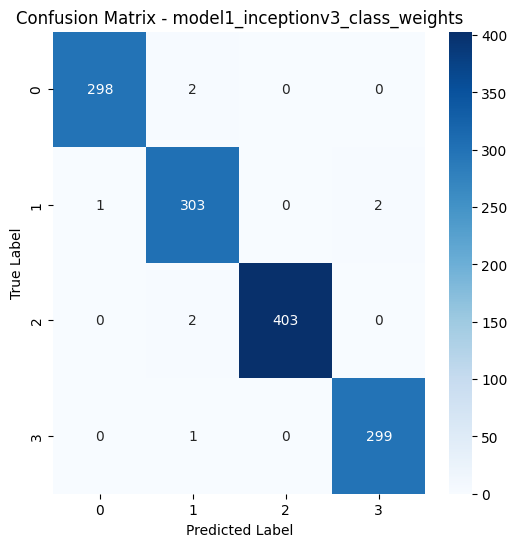

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

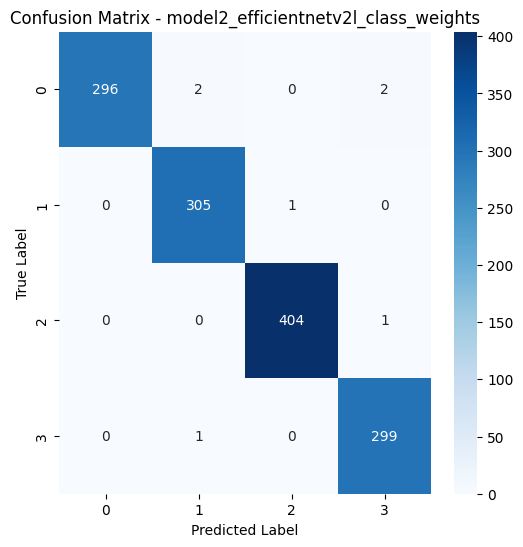

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━

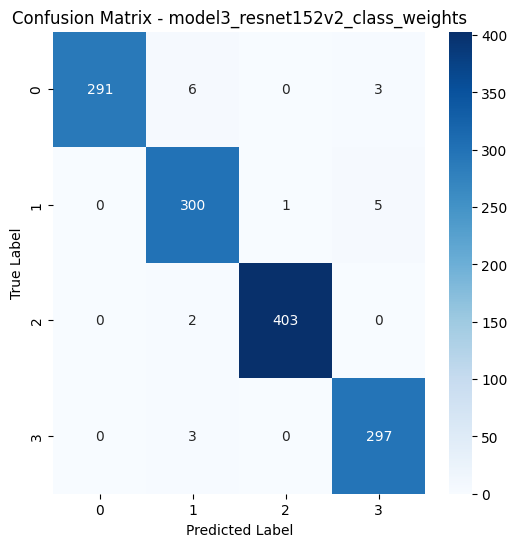

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━

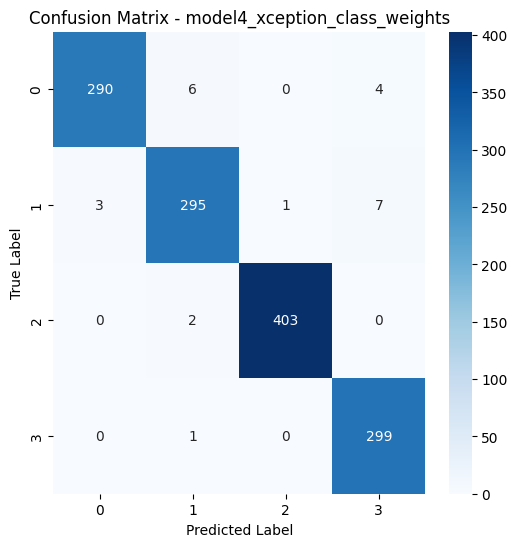

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━

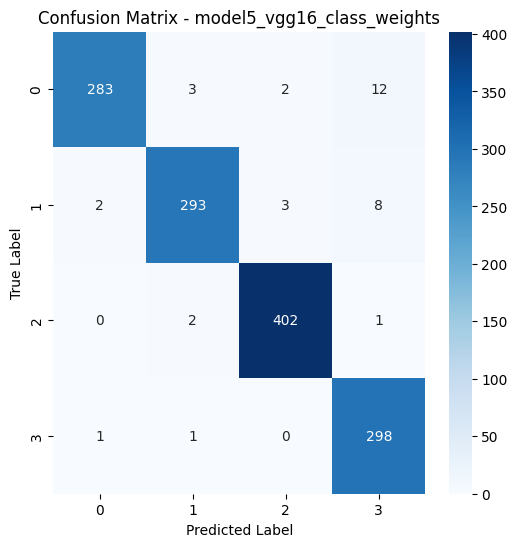

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━

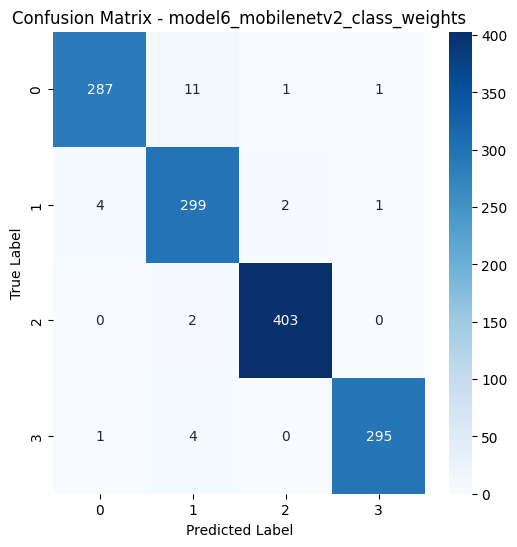

(0.9794050343249427,
 0.9797011254954492,
 0.9794050343249427,
 0.9794483593422978,
 0.02822273073989321,
 0.2157066686393808,
 array([[287,  11,   1,   1],
        [  4, 299,   2,   1],
        [  0,   2, 403,   0],
        [  1,   4,   0, 295]]))

In [14]:
# After training models
evaluate_model(model1, test_ds, 'model1_inceptionv3_class_weights')
evaluate_model(model2, test_ds, 'model2_efficientnetv2l_class_weights')
evaluate_model(model3, test_ds, 'model3_resnet152v2_class_weights')
evaluate_model(model4, test_ds, 'model4_xception_class_weights')
evaluate_model(model5, test_ds, 'model5_vgg16_class_weights')
evaluate_model(model6, test_ds, 'model6_mobilenetv2_class_weights')

# Load models

In [10]:
from tensorflow.keras.models import load_model
import os

base_path = "/kaggle/input/custom_models/tensorflow2/default/1"
print("Files in directory:")
print(os.listdir(base_path))


Files in directory:
['model5_vgg16_class_weights_best.keras', 'model6_mobilenetv2_class_weights_best.keras', 'model4_xception_class_weights.keras', 'model3_resnet152v2_class_weights.keras', 'model1_inceptionv3_class_weights_best.keras', 'model2_efficientnetv2l_class_weights_best.keras']


In [22]:
model1 = load_model('/kaggle/input/custom_models/tensorflow2/default/1/model1_inceptionv3_class_weights_best.keras')

model3 = load_model('/kaggle/input/custom_models/tensorflow2/default/1/model3_resnet152v2_class_weights.keras')
model4 = load_model('/kaggle/input/custom_models/tensorflow2/default/1/model4_xception_class_weights.keras')
model5 = load_model('/kaggle/input/custom_models/tensorflow2/default/1/model5_vgg16_class_weights_best.keras')
model6 = load_model('/kaggle/input/custom_models/tensorflow2/default/1/model6_mobilenetv2_class_weights_best.keras')
model7 = load_model('/kaggle/input/custom_cnn_updated/tensorflow2/default/1/custom_cnn_model_best.keras')
# model2 = load_model('/kaggle/input/custom_models/tensorflow2/default/1/model2_efficientnetv2l_class_weights_best.keras')

In [23]:
# Define ensembles
# ensemble1 = [model2, model4, model3]
# ensemble2 = [model1, model2, model4]
# ensemble3 = [model2, model3, model6]
ensemble1 = [model7, model4, model3]
ensemble2 = [model1, model7, model4]
ensemble3 = [model7, model3, model6]

In [24]:
def ensemble_predict(models, test_ds):
    all_predictions = []
    y_true = []

    for images, labels in test_ds:
        y_true.extend(labels.numpy())  
        preds = [model.predict(images, verbose=0) for model in models]
        all_predictions.append(np.mean(preds, axis=0)) 

    avg_predictions = np.vstack(all_predictions)  
    final_predictions = np.argmax(avg_predictions, axis=1) 
    return np.array(y_true), final_predictions, avg_predictions


In [25]:
# Function to evaluate ensemble and save results
def evaluate_and_save_ensemble(models, test_ds, model_name):
    y_true, y_pred, avg_probs = ensemble_predict(models, test_ds)

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sensitivity = np.mean(np.diag(cm) / np.sum(cm, axis=1))  
    specificity = np.mean(np.diag(cm) / np.sum(cm, axis=0)) 

    # Additional metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    # Print evaluation metrics
    print(f"\n=== Model Evaluation Metrics for {model_name} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Save results
    with open(f'{model_name}_results.pkl', 'wb') as f:
        pickle.dump({'y_true': y_true, 'y_pred': y_pred, 'avg_probs': avg_probs}, f)
    
    print(f"Ensemble '{model_name}' results saved successfully!")

    # Plot confusion matrix
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()


In [26]:
# Run evaluation for all ensembles
evaluate_and_save_ensemble(ensemble1, test_ds, "ensemble1")
evaluate_and_save_ensemble(ensemble2, test_ds, "ensemble2")
evaluate_and_save_ensemble(ensemble3, test_ds, "ensemble3")

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "conv2d_20" is incompatible with the layer: expected axis -1 of input shape to have value 1, but received input with shape (32, 224, 224, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 224, 224, 3), dtype=float32)
  • training=False
  • mask=None

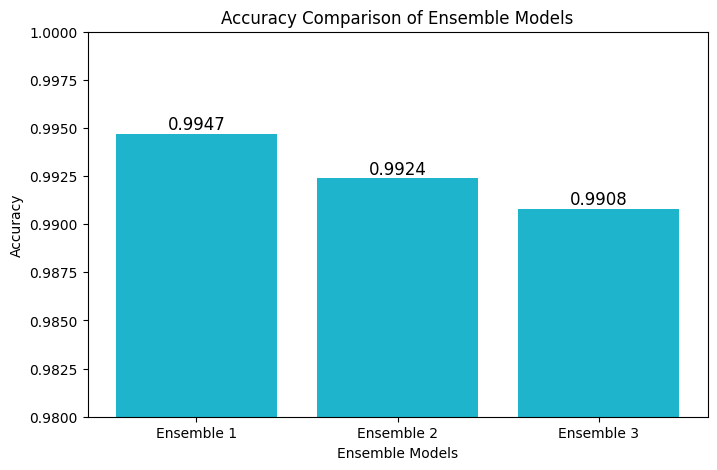

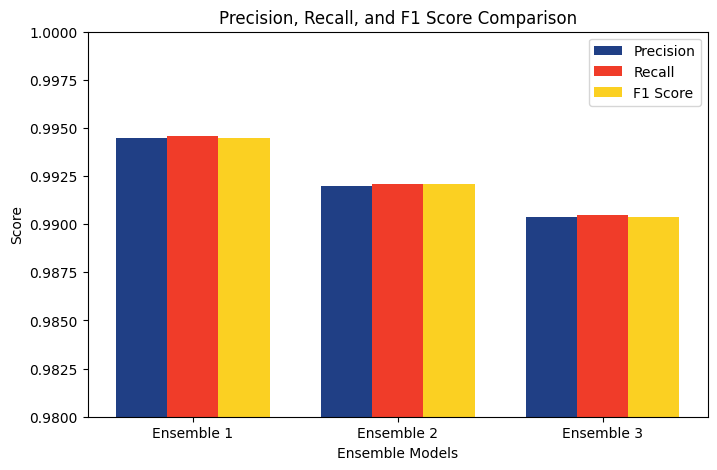

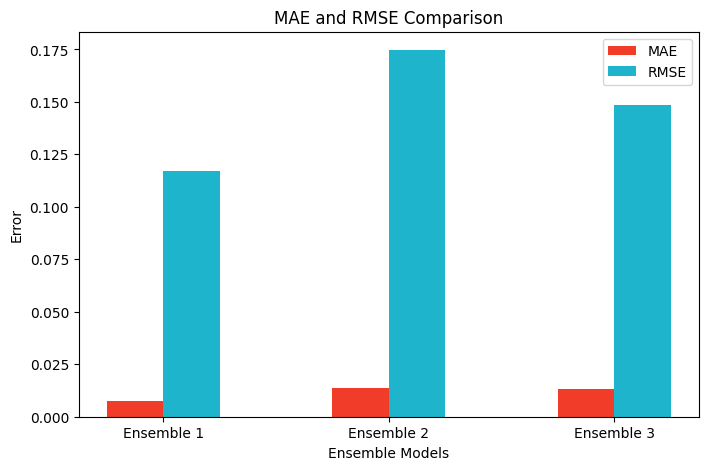

In [20]:
ensembles = ["Ensemble 1", "Ensemble 2", "Ensemble 3"]
accuracy = [0.9947, 0.9924, 0.9908]
precision = [0.9945, 0.9920, 0.9904]
recall = [0.9946, 0.9921, 0.9905]
f1_score = [0.9945, 0.9921, 0.9904]
sensitivity = [0.9946, 0.9921, 0.9905]
specificity = [0.9945, 0.9920, 0.9904]
mae = [0.0076, 0.0137, 0.0130]
rmse = [0.1172, 0.1747, 0.1487]


colors = ["#203f85", "#1eb4cb", "#fdf6de", "#f03c29", "#fbd022"]


plt.figure(figsize=(8, 5))
plt.bar(ensembles, accuracy, color=colors[1])
plt.xlabel("Ensemble Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Ensemble Models")
plt.ylim(0.98, 1.0) 
for i, v in enumerate(accuracy):
    plt.text(i, v, f"{v:.4f}", ha='center', va='bottom', fontsize=12, color='black')
plt.show()


metrics = [precision, recall, f1_score]
labels = ["Precision", "Recall", "F1 Score"]
metric_colors = [colors[0], colors[3], colors[4]] 

plt.figure(figsize=(8, 5))
bar_width = 0.25
x = np.arange(len(ensembles))

for i, metric in enumerate(metrics):
    plt.bar(x + i * bar_width, metric, width=bar_width, label=labels[i], color=metric_colors[i])

plt.xlabel("Ensemble Models")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score Comparison")
plt.xticks(x + bar_width, ensembles)
plt.legend()
plt.ylim(0.98, 1.0)
plt.show()


plt.figure(figsize=(8, 5))
bar_width = 0.25
x = np.arange(len(ensembles))

plt.bar(x, mae, width=bar_width, label="MAE", color=colors[3]) 
plt.bar(x + bar_width, rmse, width=bar_width, label="RMSE", color=colors[1]) 

plt.xlabel("Ensemble Models")
plt.ylabel("Error")
plt.title("MAE and RMSE Comparison")
plt.xticks(x + bar_width / 2, ensembles)
plt.legend()
plt.show()


In [1]:
ensembles = ["Ensemble 1", "Ensemble 2", "Ensemble 3"]
accuracy = [0.9947, 0.9924, 0.9908]
precision = [0.9945, 0.9920, 0.9904]
recall = [0.9946, 0.9921, 0.9905]
f1_score = [0.9945, 0.9921, 0.9904]
sensitivity = [0.9946, 0.9921, 0.9905]
specificity = [0.9945, 0.9920, 0.9904]
mae = [0.0076, 0.0137, 0.0130]
rmse = [0.1172, 0.1747, 0.1487]


colors = ["#203f85", "#1eb4cb", "#fdf6de", "#f03c29", "#fbd022"]


plt.figure(figsize=(8, 5))
plt.bar(ensembles, accuracy, color=colors[1])
plt.xlabel("Ensemble Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Ensemble Models")
plt.ylim(0.98, 1.0) 
for i, v in enumerate(accuracy):
    plt.text(i, v, f"{v:.4f}", ha='center', va='bottom', fontsize=12, color='black')
plt.show()


metrics = [precision, recall, f1_score]
labels = ["Precision", "Recall", "F1 Score"]
metric_colors = [colors[0], colors[3], colors[4]] 

plt.figure(figsize=(8, 5))
bar_width = 0.25
x = np.arange(len(ensembles))

for i, metric in enumerate(metrics):
    plt.bar(x + i * bar_width, metric, width=bar_width, label=labels[i], color=metric_colors[i])

plt.xlabel("Ensemble Models")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score Comparison")
plt.xticks(x + bar_width, ensembles)
plt.legend()
plt.ylim(0.98, 1.0)
plt.show()


plt.figure(figsize=(8, 5))
bar_width = 0.25
x = np.arange(len(ensembles))

plt.bar(x, mae, width=bar_width, label="MAE", color=colors[3]) 
plt.bar(x + bar_width, rmse, width=bar_width, label="RMSE", color=colors[1]) 

plt.xlabel("Ensemble Models")
plt.ylabel("Error")
plt.title("MAE and RMSE Comparison")
plt.xticks(x + bar_width / 2, ensembles)
plt.legend()
plt.show()


NameError: name 'plt' is not defined

In [21]:
!zip -r /kaggle/working/all_outputs.zip /kaggle/working/

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/model1_inceptionv3_class_weights_history.json (deflated 75%)
  adding: kaggle/working/model6_mobilenetv2_class_weights_computation_time.txt (deflated 30%)
  adding: kaggle/working/model3_resnet152v2_class_weights_evaluation.json (deflated 50%)
  adding: kaggle/working/ensemble3_results.pkl (deflated 45%)
  adding: kaggle/working/model4_xception_class_weights_evaluation.json (deflated 50%)
  adding: kaggle/working/model2_efficientnetv2l_class_weights_history.json (deflated 75%)
  adding: kaggle/working/model5_vgg16_class_weights_evaluation.json (deflated 50%)
  adding: kaggle/working/model3_resnet152v2_class_weights_history.json (deflated 74%)
  adding: kaggle/working/model3_resnet152v2_class_weights.keras (deflated 8%)
  adding: kaggle/working/model2_efficientnetv2l_class_weights_computation_time.txt (deflated 30%)
  adding: kaggle/working/model6_mobilenetv2_class_wei

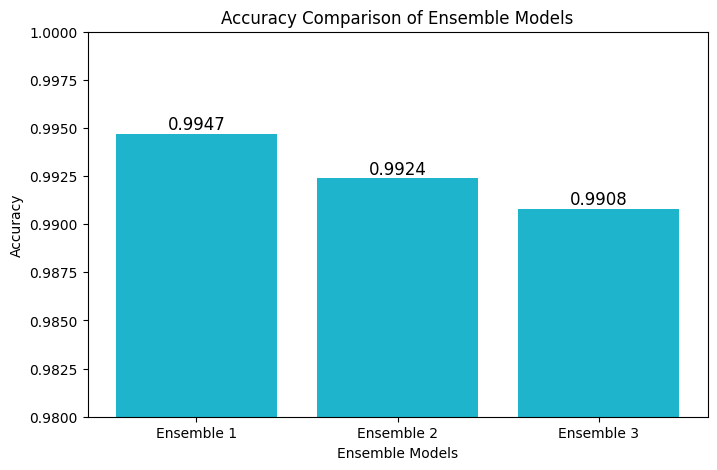

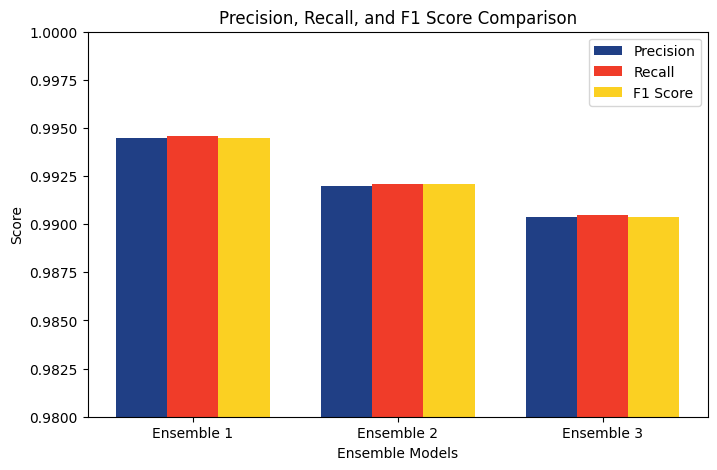

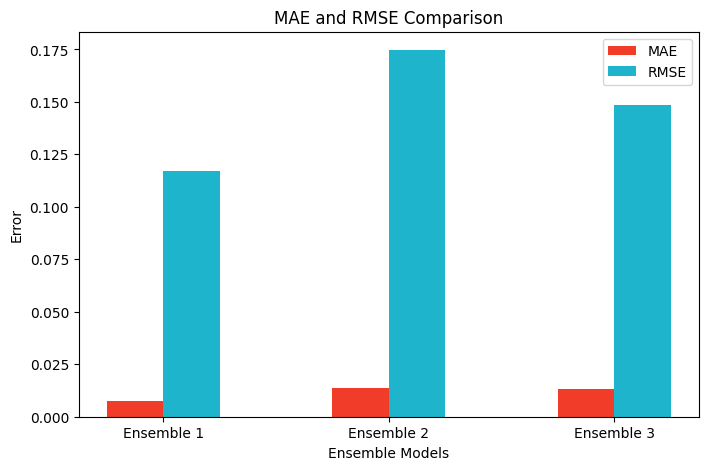

In [22]:
ensembles = ["Ensemble 1", "Ensemble 2", "Ensemble 3"]
accuracy = [0.9947, 0.9924, 0.9908]
precision = [0.9945, 0.9920, 0.9904]
recall = [0.9946, 0.9921, 0.9905]
f1_score = [0.9945, 0.9921, 0.9904]
sensitivity = [0.9946, 0.9921, 0.9905]
specificity = [0.9945, 0.9920, 0.9904]
mae = [0.0076, 0.0137, 0.0130]
rmse = [0.1172, 0.1747, 0.1487]


colors = ["#203f85", "#1eb4cb", "#fdf6de", "#f03c29", "#fbd022"]


plt.figure(figsize=(8, 5))
plt.bar(ensembles, accuracy, color=colors[1])
plt.xlabel("Ensemble Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Ensemble Models")
plt.ylim(0.98, 1.0) 
for i, v in enumerate(accuracy):
    plt.text(i, v, f"{v:.4f}", ha='center', va='bottom', fontsize=12, color='black')
plt.show()


metrics = [precision, recall, f1_score]
labels = ["Precision", "Recall", "F1 Score"]
metric_colors = [colors[0], colors[3], colors[4]] 

plt.figure(figsize=(8, 5))
bar_width = 0.25
x = np.arange(len(ensembles))

for i, metric in enumerate(metrics):
    plt.bar(x + i * bar_width, metric, width=bar_width, label=labels[i], color=metric_colors[i])

plt.xlabel("Ensemble Models")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score Comparison")
plt.xticks(x + bar_width, ensembles)
plt.legend()
plt.ylim(0.98, 1.0)
plt.show()


plt.figure(figsize=(8, 5))
bar_width = 0.25
x = np.arange(len(ensembles))

plt.bar(x, mae, width=bar_width, label="MAE", color=colors[3]) 
plt.bar(x + bar_width, rmse, width=bar_width, label="RMSE", color=colors[1]) 

plt.xlabel("Ensemble Models")
plt.ylabel("Error")
plt.title("MAE and RMSE Comparison")
plt.xticks(x + bar_width / 2, ensembles)
plt.legend()
plt.show()
